<center> Week 3-4 Exercise: White House Visitors<center>
<center>Caitie Schrotberger<center>
<center>Bellevue University<center>
<center>DSC640-T301 Advanced Uses of Generative AI (2265-1)<center>
<center>Benjamin Schneider<center>
<center>March 28, 2026<center>

Assignment Instructions \
You are provided 25 datasets that contain information on who visited the White House, when, and for what purpose. For this exercise, you must craft a story about the data based on the following parameters: Audience, Purpose, Medium, Design, Visuals, Ethical Considerations. \
To get started, analyze the data and determine what looks interesting. You are welcome to make things up, role play, have fun with these exercises. \
You must use at least 5 datasets provided to provide a visual story with the data with whatever medium you are choosing to present your story and remember it must include a call to action. The data is in the same format in each CSV, but unfortunately broken out by month vs being in one consolidated file. \
This exercise must be done using Python for your visuals. \
You must define an audience, purpose, and medium to tell your story. \
You must have at least 6 visuals included that use the data provided and 4 must be from this list: Bar & Column Charts, Stacked Bars with Time, Scatterplots with Time, Line Charts, Step Charts \
Include a 250-500-word paper summarizing your audience, purpose, medium and design choices along with the above ethical consideration questions.



In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, MultipleLocator
import glob
import os

In [2]:
rename_map = {
    'Last Name': 'LastName',
    'First Name': 'FirstName',
    'Middle Initial': 'MiddleInitial',
    'UIN': 'UIN',
    'BDGNBR': 'BDGNBR',
    'Access Type': 'AccessType',
    'TOA': 'TOA',
    'POA': 'POA',
    'TOD': 'TOD',
    'POD': 'POD',
    'Appointment Made Date': 'ApptMadeDate',
    'Appointment Start Date': 'ApptStartDate',
    'Appointment End Date': 'ApptEndDate',
    'Appointment Cancel Date': 'ApptCancelDate',
    'Total People': 'TotalPeople',
    'Last Updated By': 'LastUpdatedBy',
    'POST': 'POST',
    'Last Entry Date': 'LastEntryDate',
    'Terminal Suffix': 'TerminalSuffix',
    'Visitee Last Name': 'VisiteeLastName',
    'Visitee First Name': 'VisiteeFirstName',
    'Meeting Location': 'MeetingLocation',
    'Meeting Room': 'MeetingRoom',
    'Caller Last Name': 'CallerLastName',
    'Caller First Name': 'CallerFirstName',
    'CALLER_ROOM': 'CALLERROOM',
    'RELEASEDATE': 'RELEASEDATE',
    'source': 'Source',
    'NAMELAST': 'LastName',
    'NAMEFIRST': 'FirstName',
    'NAMEMID': 'MiddleInitial',
    'ACCESS_TYPE': 'AccessType',
    'APPT_MADE_DATE': 'ApptMadeDate',
    'APPT_START_DATE': 'ApptStartDate',
    'APPT_END_DATE': 'ApptEndDate',
    'APPT_CANCEL_DATE': 'ApptCancelDate',
    'TOTAL_PEOPLE': 'TotalPeople',
    'LAST_UPDATEDBY': 'LastUpdatedBy',
    'LASTENTRYDATE': 'LastEntryDate',
    'TERMINAL_SUFFIX': 'TerminalSuffix',
    'VISITEE_NAMELAST': 'VisiteeLastName',
    'VISITEE_NAMEFIRST': 'VisiteeFirstName',
    'MEETING_LOC': 'MeetingLocation',
    'MEETING_ROOM': 'MeetingRoom',
    'CALLER_NAME_LAST': 'CallerLastName',
    'CALLER_NAME_FIRST': 'CallerFirstName',
    'Caller Room': 'CALLERROOM',
    'Release Date': 'RELEASEDATE',
    'Unnamed: 27': 'Unkn27',
    'Unnamed: 28': 'Unkn28'
}

In [3]:
# Only 2023 files are included in this folder
path = 'G:/My Drive/College/Caitie/DSC640-T301/Weeks3&4Exercise'
all_files = glob.glob(os.path.join(path, "*.csv"))

In [4]:
vlog = []
for f in all_files:
    df = pd.read_csv(f, low_memory=False)
    df = df.rename(columns=rename_map)
    vlog.append(df)

visitlogs = pd.concat(vlog, ignore_index=True)

In [5]:
# Convert date fields to dates  ApptMadeDate
visitlogs['ApptMadeDate'] = pd.to_datetime(visitlogs['ApptMadeDate'], errors='coerce')
visitlogs['ApptStartDate'] = pd.to_datetime(visitlogs['ApptStartDate'], errors='coerce')
visitlogs['ApptEndDate'] = pd.to_datetime(visitlogs['ApptEndDate'], errors='coerce')
visitlogs['TOA'] = pd.to_datetime(visitlogs['TOA'], format='%b %d %Y %I:%M%p', errors='coerce')
visitlogs['LastEntryDate'] = pd.to_datetime(visitlogs['LastEntryDate'], errors='coerce')
visitlogs['RELEASEDATE'] = pd.to_datetime(visitlogs['RELEASEDATE'], errors='coerce')

In [6]:
# To focus on one location filtering to WH (White House) only
whitehouse=visitlogs.query("MeetingLocation == 'WH'")

In [7]:
# Adding field to group rooms together for better visualization
mapping = {
    "Oval": "Oval Office",
    "Tour": "Tour",
    "Brief": "Briefing Room",
    "Ellipse": "Ellipse",
    "Navy": "Navy Mess",
    "Pebble": "Pebble Beach",
    "Press": "Press Room",
    "Res": "Residence",
    "Roos": "Roosevelt Room",
    "Rose": "Rose Garden",
    "Lawn": "South Lawn",
    "State": "State Floor",
    "WHSR": "State Floor",
    "West": "West Wing",
    "WW": "West Wing",
    "EW": "East Wing",
    "East": "East Wing"
}

def categorize(room):
    room = str(room)  # ensure it's a string
    for key, value in mapping.items():
        if key in room:
            return value
    return "Other"

whitehouse["RoomGroup"] = whitehouse["MeetingRoom"].apply(categorize)

In [8]:
# Binning number of people
bins = [0, 4, 10, 20, 50, 100, 250, 500, 1000, float('inf')]
labels = [
    "1–4",
    "5–10",
    "11–20",
    "21–50",
    "51–100",
    "101–250",
    "251–500",
    "501–1000",
    "1001+"]

whitehouse["PeopleBin"] = pd.cut(
    whitehouse["TotalPeople"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True)

In [9]:
# Adding other fields for visualizations
whitehouse['Month'] = whitehouse['ApptStartDate'].dt.month
whitehouse['ApptMinutes'] = (whitehouse['ApptStartDate'].dt.hour * 60 + visitlogs['ApptStartDate'].dt.minute)
whitehouse['ArrivalMinutes'] = (whitehouse['TOA'].dt.hour * 60 + visitlogs['TOA'].dt.minute)

In [10]:
# Removing mostly empty columns or columns not of value to analysis
whitehouse = whitehouse.drop(columns=['MiddleInitial','UIN','POA', 'TOD', 'POD','ApptCancelDate','CALLERROOM','POST','TerminalSuffix'])

In [11]:
whitehouse.info()

<class 'pandas.DataFrame'>
Index: 700893 entries, 2 to 842859
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LastName          700838 non-null  str           
 1   FirstName         700888 non-null  str           
 2   BDGNBR            24168 non-null   float64       
 3   AccessType        700893 non-null  str           
 4   TOA               496405 non-null  datetime64[us]
 5   ApptMadeDate      700893 non-null  datetime64[us]
 6   ApptStartDate     700893 non-null  datetime64[us]
 7   ApptEndDate       700893 non-null  datetime64[us]
 8   TotalPeople       700893 non-null  float64       
 9   LastUpdatedBy     700893 non-null  str           
 10  LastEntryDate     700893 non-null  datetime64[us]
 11  VisiteeLastName   700893 non-null  str           
 12  VisiteeFirstName  650799 non-null  str           
 13  MeetingLocation   700893 non-null  str           
 14  MeetingRoom       70

In [12]:
whitehouse.head(10)

,LastName,FirstName,BDGNBR,AccessType,TOA,ApptMadeDate,ApptStartDate,ApptEndDate,TotalPeople,LastUpdatedBy,...,MeetingLocation,MeetingRoom,CallerLastName,CallerFirstName,RELEASEDATE,RoomGroup,PeopleBin,Month,ApptMinutes,ArrivalMinutes
2,AAGAARD,ANDREW,NaN,VA,2023-12-10 20:09:00,2023-12-08 12:04:00,2023-12-10 20:00:00,2023-12-10 23:59:00,50.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,21–50,12,1200.0,1209.0
3,AAL,MICHAEL,NaN,VA,2023-12-05 11:40:00,2023-11-28 04:04:00,2023-12-05 12:00:00,2023-12-05 23:59:00,4.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,1–4,12,720.0,700.0
4,AAL,SABINE,NaN,VA,2023-12-05 11:40:00,2023-11-28 04:04:00,2023-12-05 12:00:00,2023-12-05 23:59:00,4.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,1–4,12,720.0,700.0
5,AALBERS,SYDNEY,NaN,VA,2023-12-07 11:39:00,2023-11-30 04:03:00,2023-12-07 12:00:00,2023-12-07 23:59:00,4.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,1–4,12,720.0,699.0
6,AANDAHL,MADELINE,NaN,VA,2023-12-17 11:47:00,2023-12-16 17:25:00,2023-12-17 11:30:00,2023-12-17 23:59:00,3.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,1–4,12,690.0,707.0
7,AANDAHL,NICOLE,NaN,VA,2023-12-17 11:47:00,2023-12-16 17:25:00,2023-12-17 11:30:00,2023-12-17 23:59:00,3.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,1–4,12,690.0,707.0
8,AANDAHL,SPENCER,NaN,VA,2023-12-17 11:47:00,2023-12-16 17:25:00,2023-12-17 11:30:00,2023-12-17 23:59:00,3.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,1–4,12,690.0,707.0
9,AANGEENBRUG,ELIZABETH,NaN,VA,2023-12-10 15:54:00,2023-12-08 07:33:00,2023-12-10 15:30:00,2023-12-10 23:59:00,50.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,21–50,12,930.0,954.0
10,AARON,AMANDA,NaN,VA,NaT,2023-12-02 02:03:00,2023-12-04 10:00:00,2023-12-04 23:59:00,48.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,21–50,12,600.0,NaN
11,AARONSON,AUSTIN,NaN,VA,2023-12-09 19:19:00,2023-12-07 11:33:00,2023-12-09 19:30:00,2023-12-09 23:59:00,4.0,VW,...,WH,EW TOUR,WAVES,VISITORSOFFICE,2024-03-30,East Wing,1–4,12,1170.0,1159.0


In [13]:
whitehouse.describe()

,BDGNBR,TOA,ApptMadeDate,ApptStartDate,ApptEndDate,TotalPeople,LastEntryDate,RELEASEDATE,Month,ApptMinutes,ArrivalMinutes
count,24168.000000,496405,700893,700893,700893,700893.000000,700893,700893,700893.000000,700893.000000,496405.000000
mean,202287.261172,2023-07-18 19:05:49.590395,2023-07-13 01:56:16.213429,2023-07-18 11:29:30.121688,2023-07-18 23:48:57.080010,75.498795,2023-07-14 12:35:23.789052,2023-10-31 22:45:21.060133,7.063801,699.550695,712.206378
min,186980.000000,2023-01-03 07:56:00,2022-12-16 08:18:00,2023-01-01 07:00:00,2023-01-01 23:59:00,1.000000,2022-12-18 10:06:00,2023-04-30 00:00:00,1.000000,0.000000,271.000000
25%,199369.000000,2023-04-29 09:53:00,2023-04-25 13:01:00,2023-04-29 11:30:00,2023-04-29 23:59:00,4.000000,2023-04-26 08:49:00,2023-07-30 00:00:00,4.000000,570.000000,581.000000
50%,201646.000000,2023-07-11 12:32:00,2023-07-03 21:00:00,2023-07-08 08:30:00,2023-07-08 23:59:00,6.000000,2023-07-05 06:33:00,2023-10-30 00:00:00,7.000000,660.000000,658.000000
75%,205381.000000,2023-10-18 08:39:00,2023-10-10 04:34:00,2023-10-17 10:30:00,2023-10-17 23:59:00,24.000000,2023-10-11 12:08:00,2024-01-30 00:00:00,10.000000,750.000000,755.000000
max,208998.000000,2023-12-31 10:01:00,2023-12-30 13:20:00,2023-12-31 10:00:00,2023-12-31 23:59:00,2775.000000,2023-12-30 13:21:00,2024-03-30 00:00:00,12.000000,1435.000000,1405.000000
std,3428.683111,NaN,NaN,NaN,NaN,245.172577,NaN,NaN,3.304151,197.593602,194.719308


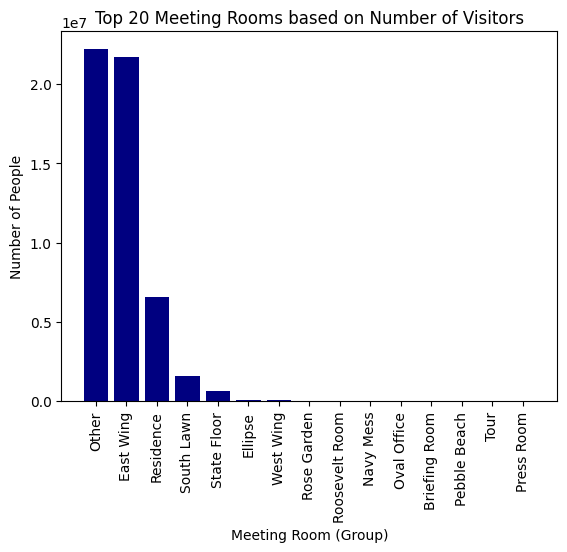

In [14]:
# Bar Chart Number of visitors by Meeting Room
V1 = (
    whitehouse
    .groupby('RoomGroup', as_index=False)['TotalPeople']
    .sum()
    .sort_values('TotalPeople', ascending=False) 
    .head(20))
plt.bar(x=V1['RoomGroup'], height=V1['TotalPeople'], color='navy')
plt.xticks(rotation=90)
plt.title("Top 20 Meeting Rooms based on Number of Visitors")
plt.xlabel("Meeting Room (Group)")
plt.ylabel("Number of People")
plt.show()

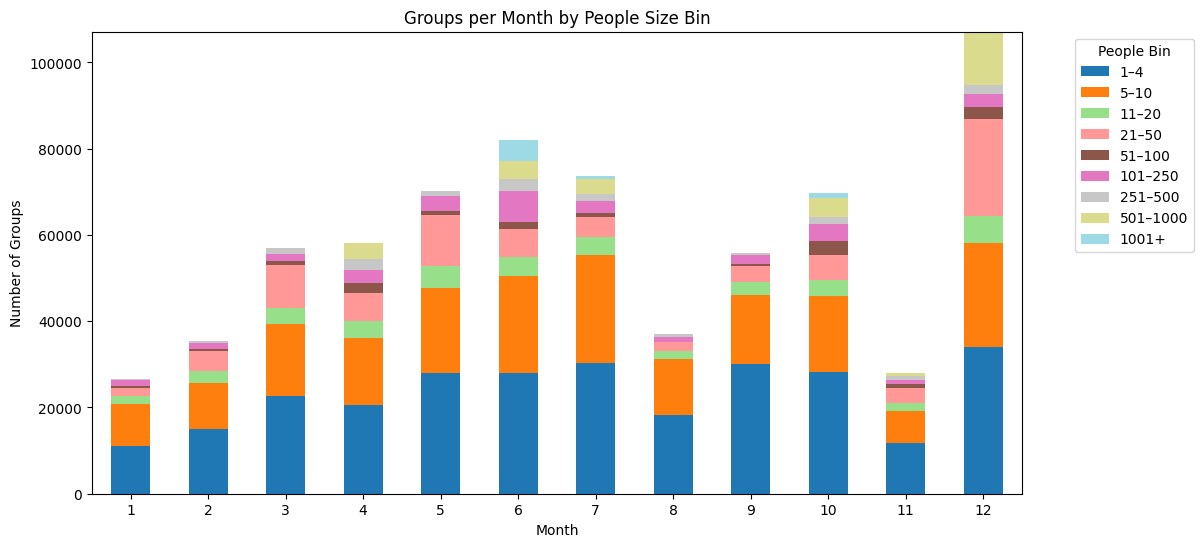

In [15]:
# Stacked Bar Chart:  Size of Peop by month of visit
V2 = (whitehouse.groupby(['Month', 'PeopleBin'], as_index=False).size().rename(columns={'size': 'GroupCount'}))
V2_wide = V2.pivot(index='Month',columns='PeopleBin',values='GroupCount').fillna(0)
ax = V2_wide.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20')
ax.legend(title="People Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.xlabel("Month")
plt.ylabel("Number of Groups")
plt.title("Groups per Month by People Size Bin")
plt.show()


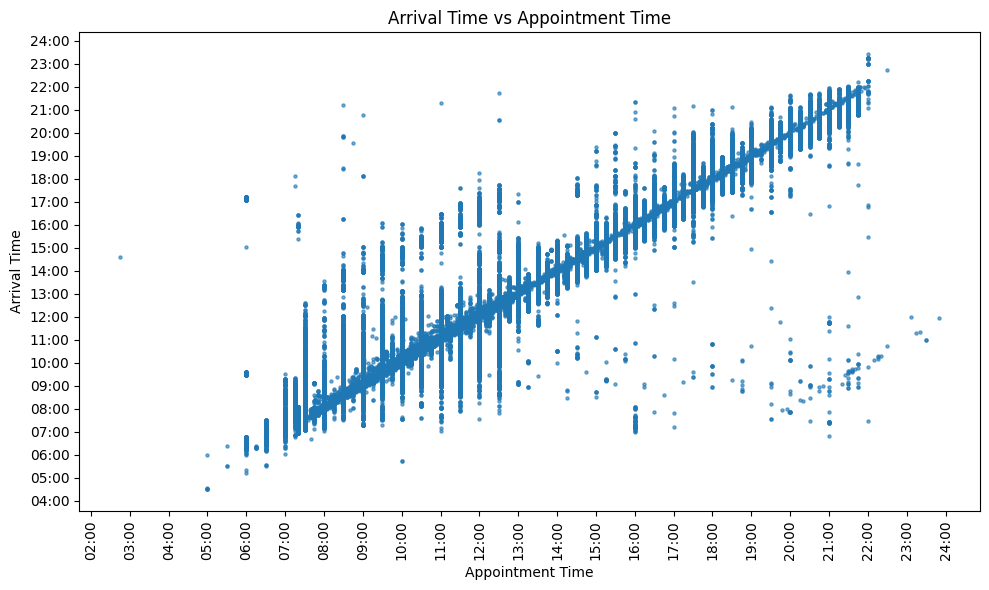

In [16]:
#Scatter Plot of number of appointments by time of day
def minutes_to_hour_label(x, pos):
    h = int(x // 60)
    return f"{h:02d}:00"

plt.figure(figsize=(10,6))
plt.scatter(
    whitehouse['ApptMinutes'],
    whitehouse['ArrivalMinutes'],
    s=5,
    alpha=0.6)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(60))
ax.yaxis.set_major_locator(MultipleLocator(60))
ax.xaxis.set_major_formatter(FuncFormatter(minutes_to_hour_label))
ax.yaxis.set_major_formatter(FuncFormatter(minutes_to_hour_label))
plt.xlabel("Appointment Time")
plt.ylabel("Arrival Time")
plt.title("Arrival Time vs Appointment Time")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

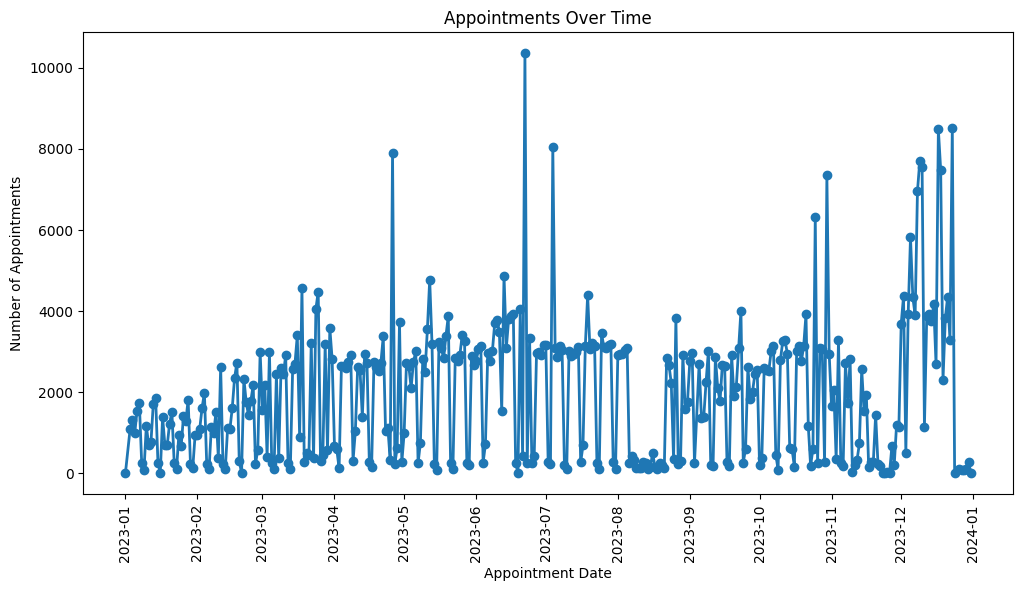

In [17]:
# Daily counts by appointment date
daily_counts = whitehouse.groupby(visitlogs['ApptStartDate'].dt.date).size()
plt.figure(figsize=(12,6))
plt.plot(daily_counts.index, daily_counts.values, marker='o', linewidth=2)
plt.xlabel("Appointment Date")
plt.ylabel("Number of Appointments")
plt.title("Appointments Over Time")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=90)
plt.show()


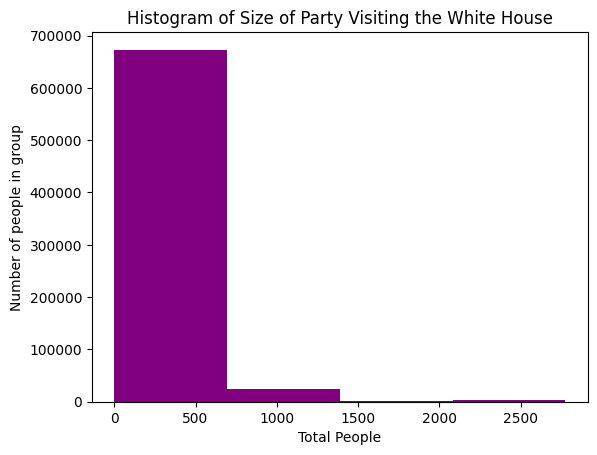

In [18]:
# Histogram of party size
V5 = whitehouse[['TotalPeople']]
V5['TotalPeople'] = V5['TotalPeople'].fillna(0)
V5 = V5.drop(V5[V5['TotalPeople'] == 0].index)
plt.hist(V5.TotalPeople, bins=4, color='purple')
plt.title('Histogram of Size of Party Visiting the White House')
plt.xlabel('Total People')
plt.ylabel('Number of people in group')
plt.show()

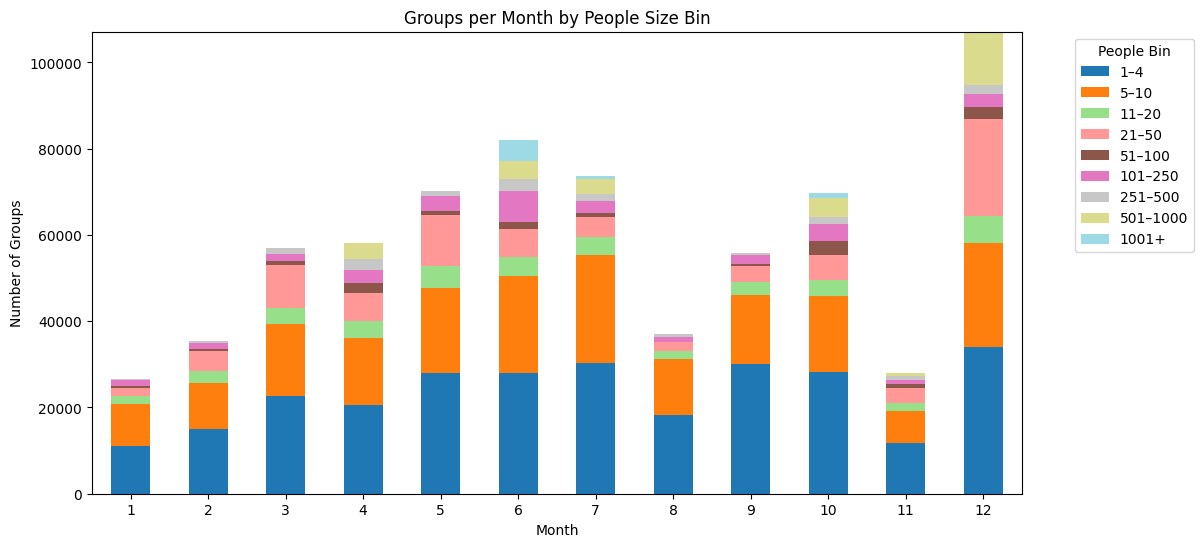

In [19]:
# Stacked Bar Chart:  Size of Peop by month of visit
V2 = (whitehouse.groupby(['Month', 'PeopleBin'], as_index=False).size().rename(columns={'size': 'GroupCount'}))
V2_wide = V2.pivot(index='Month',columns='PeopleBin',values='GroupCount').fillna(0)
ax = V2_wide.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20')
ax.legend(title="People Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.xlabel("Month")
plt.ylabel("Number of Groups")
plt.title("Groups per Month by People Size Bin")
plt.show()


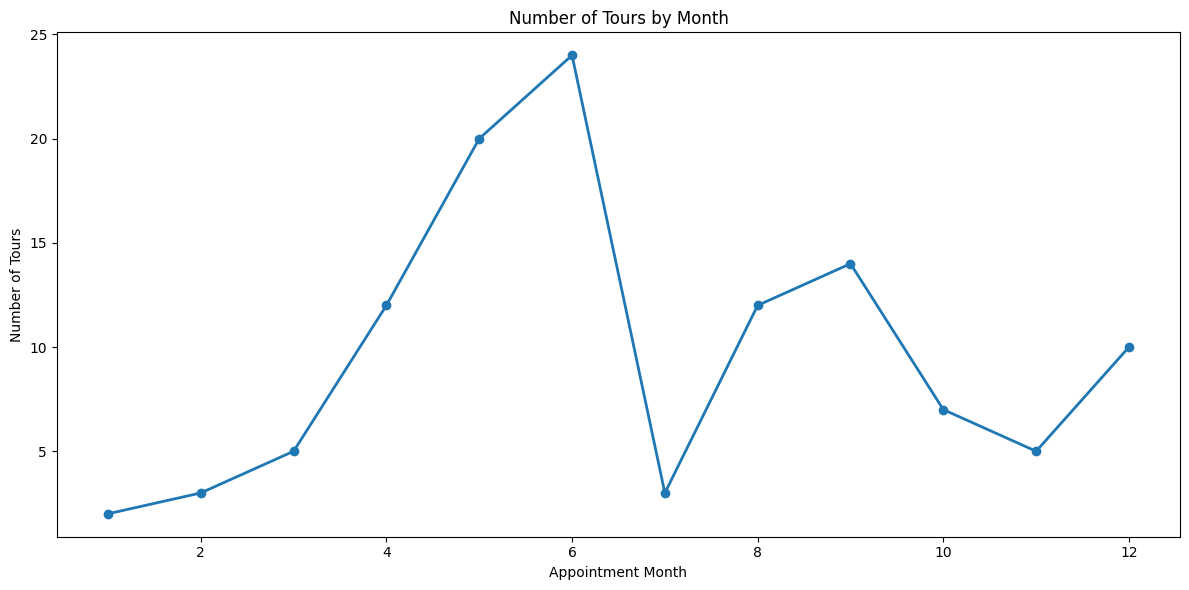

In [20]:
# Tours by Month
tours=whitehouse.query("RoomGroup == 'Tour'")
tour_counts = tours.groupby(tours['Month']).size()
plt.figure(figsize=(12,6))
plt.plot(tour_counts.index, tour_counts.values, marker='o', linewidth=2)
plt.xlabel("Appointment Month")
plt.ylabel("Number of Tours")
plt.title("Number of Tours by Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()